# Lecture 12 — Capstone: End-to-End ML Project & Responsible ML

**Learning objectives**

By the end of this lecture you will be able to:

- Frame a business problem as a supervised learning task and choose metrics that reflect the real costs of errors.
- Run a complete, leakage-free workflow on messy tabular data: EDA, stratified splitting, preprocessing with `ColumnTransformer`, baselines, cross-validated model comparison and hyperparameter search.
- Turn probabilities into decisions by tuning the classification threshold for a cost matrix, and justify the choice with decision theory.
- Evaluate the final model once on a held-out test set with uncertainty estimates, and interpret it with permutation importance and partial dependence plots.
- Audit a model for group fairness (TPR/FPR by group, demographic parity and equalised odds differences) and understand the trade-offs and impossibility results.
- Document a model with a model card, persist it, and plan monitoring for data drift in deployment.

**Prerequisites**

This capstone draws on the whole course, in particular:

- [`03_logistic_regression_and_classification.ipynb`](03_logistic_regression_and_classification.ipynb) (logistic regression, ROC/PR curves, class imbalance).
- [`04_model_evaluation_and_selection.ipynb`](04_model_evaluation_and_selection.ipynb) (cross-validation, hyperparameter search, leakage, calibration).
- [`07_decision_trees_and_ensembles.ipynb`](07_decision_trees_and_ensembles.ipynb) (random forests, gradient boosting).
- [`10_neural_networks_from_scratch.ipynb`](10_neural_networks_from_scratch.ipynb) and [`11_deep_learning_with_pytorch.ipynb`](11_deep_learning_with_pytorch.ipynb) (for context: why gradient-boosted trees remain the default for tabular data).

**Contents**

1. The problem: credit default risk
2. A reproducible synthetic dataset
3. Framing the problem and choosing metrics
4. Exploratory data analysis
5. Train/test split and preprocessing with `ColumnTransformer`
6. Baseline
7. Candidate models with cross-validation
8. Hyperparameter search
9. From probabilities to decisions: threshold tuning for a cost matrix
10. Final evaluation on the test set
11. Model interpretation: permutation importance and partial dependence
12. Fairness analysis
13. Documentation: a model card
14. Deployment: persistence, monitoring and data drift
15. Pitfalls & practical tips
16. Exercises
17. Capstone assignment brief and grading rubric
18. Summary and further reading

In [1]:
%matplotlib inline
import os, json, time, tempfile, warnings
from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn
from scipy import stats
from IPython.display import Markdown, display

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate, cross_val_predict,
                                     GridSearchCV, RandomizedSearchCV, TunedThresholdClassifierCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss, roc_curve,
                             precision_recall_curve, confusion_matrix, make_scorer)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)
rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (7, 4.5)
pd.set_option("display.width", 120, "display.max_columns", 20, "display.precision", 3)
SEED = 42

## 1. The problem: credit default risk

A (fictional) lender receives loan applications and must decide whether to **approve** or **reject** each one. Approved loans that later **default** are expensive; rejecting applicants who would have repaid loses the interest the lender would have earned — and, from the applicant's side, denies credit to someone who deserved it. Management asks the data-science team for a model that:

- ranks applicants by default risk,
- supports an approve/reject decision that minimises expected cost,
- is explainable to regulators and applicants,
- does not systematically disadvantage a protected group,
- can be deployed and monitored.

This is a typical end-to-end project: most of the work is *not* choosing the algorithm but framing, data handling, evaluation, and responsible deployment. Throughout, we follow a strict protocol: **the test set is touched exactly once**, at the end (Section 10).

## 2. A reproducible synthetic dataset

Real credit data are confidential, so we simulate a realistic dataset with a known data-generating process (which also lets us check what our interpretation tools recover). It has:

- **numeric** features: age, income, employment years, loan amount, credit score, debt-to-income ratio, number of late payments, number of open accounts;
- **categorical** features: home ownership, loan purpose, term, region;
- **missing values**, some *missing at random given other features* (employment years is more often missing for renters) — not just completely at random;
- **class imbalance** (roughly 13–14% defaults);
- a **sensitive attribute** `group` $\in\{A, B\}$ (a stand-in for a legally protected characteristic). It has **no direct effect** on default in the simulation, but it is correlated with income (a historical disadvantage) and with region — so other features act as **proxies** for it.

The generator takes a `shift` argument that we will use in Section 14 to simulate a recession for drift monitoring.

In [2]:
def make_loan_data(n=8000, seed=42, shift=False):
    # Simulate loan applications and default outcomes. shift=True simulates an economic downturn.
    r = np.random.default_rng(seed)
    region = r.choice(["North", "South", "East", "West"], size=n, p=[0.3, 0.25, 0.25, 0.2])
    p_B = np.select([region == "South", region == "East"], [0.55, 0.30], default=0.15)
    group = np.where(r.random(n) < p_B, "B", "A")                       # sensitive attribute
    age = np.clip(r.normal(41, 12, n), 18, 75).round().astype(int)
    log_inc = (np.log(52000) + 0.35 * np.tanh((age - 30) / 15) - 0.35 * (group == "B")
               + r.normal(0, 0.45, n) - (0.30 if shift else 0.0))       # downturn: incomes fall ~26%
    income = np.exp(log_inc).round(-2)
    employment_years = np.clip((age - 18) * r.uniform(0, 0.7, n) + r.normal(0, 1.5, n), 0, 45).round(1)
    p_rent = 1 / (1 + np.exp(1.2 * (log_inc - np.log(52000)) / 0.45 + (age - 38) / 10))
    home = np.where(r.random(n) < p_rent, "RENT", np.where(r.random(n) < 0.7, "MORTGAGE", "OWN"))
    purpose_p = [0.28, 0.18, 0.10, 0.08, 0.16, 0.20] if shift else [0.35, 0.2, 0.15, 0.12, 0.10, 0.08]
    purpose = r.choice(["debt_consolidation", "credit_card", "home_improvement", "car", "medical",
                        "small_business"], size=n, p=purpose_p)
    loan_amount = np.clip(np.exp(np.log(0.22 * income) + r.normal(0, 0.5, n)), 1000, 60000).round(-2)
    term = np.where(r.random(n) < 0.3 + 0.2 * (loan_amount > 20000), "60 months", "36 months")
    late = r.poisson(0.5 + 0.3 * (home == "RENT") + (0.6 if shift else 0.0), n)
    open_acc = r.poisson(7, n)
    dti = np.clip(r.beta(2, 5, n) * 0.5 + 0.25 * loan_amount / income, 0, 1.5).round(3)
    credit = np.clip(680 + 30 * (log_inc - np.log(52000)) / 0.45 + 2 * np.minimum(employment_years, 15)
                     - 22 * late + r.normal(0, 35, n), 300, 850).round()
    purpose_eff = pd.Series(purpose).map({"debt_consolidation": 0.0, "credit_card": 0.1, "home_improvement": -0.2,
                                          "car": -0.3, "medical": 0.3, "small_business": 0.7}).to_numpy()
    # true log-odds of default: note there is NO direct term for `group` or `region`
    logit = (-2.7 - 0.016 * (credit - 680) + 4.0 * (dti - 0.2) + 10.0 * np.maximum(dti - 0.3, 0) + 0.25 * late
             + 0.45 * (term == "60 months") - 0.3 * (log_inc - np.log(52000)) + purpose_eff
             + 0.25 * (home == "RENT") - 0.04 * np.minimum(employment_years, 10) + 0.0012 * (age - 45) ** 2
             + 1.0 * (purpose == "small_business") * (credit < 650))          # an interaction
    default = (r.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
    df = pd.DataFrame({"age": age, "income": income, "employment_years": employment_years,
                       "home_ownership": home, "purpose": purpose, "loan_amount": loan_amount, "term": term,
                       "credit_score": credit, "debt_to_income": dti, "num_late_payments": late,
                       "num_open_accounts": open_acc, "region": region, "group": group, "default": default})
    # missingness: MCAR for income/credit score, MAR (depends on home ownership) for employment years
    df.loc[r.random(n) < 0.04, "income"] = np.nan
    df.loc[r.random(n) < np.where(home == "RENT", 0.15, 0.04), "employment_years"] = np.nan
    df.loc[r.random(n) < (0.15 if shift else 0.05), "credit_score"] = np.nan
    df.loc[r.random(n) < 0.02, "home_ownership"] = np.nan
    return df

df = make_loan_data()
print(df.shape)
df.head()

(8000, 14)


,age,income,employment_years,home_ownership,purpose,loan_amount,term,credit_score,debt_to_income,num_late_payments,num_open_accounts,region,group,default
0,36,148400.0,2.2,MORTGAGE,small_business,35100.0,60 months,798.0,0.077,0,5,East,A,0
1,66,65800.0,18.4,MORTGAGE,debt_consolidation,13300.0,60 months,728.0,0.211,1,13,South,A,0
2,33,47300.0,8.5,RENT,home_improvement,9700.0,36 months,694.0,0.210,1,2,West,A,1
3,39,36300.0,6.5,OWN,debt_consolidation,8100.0,60 months,615.0,0.089,1,9,East,B,0
4,30,62000.0,NaN,RENT,debt_consolidation,16500.0,36 months,NaN,0.187,0,8,North,A,0


## 3. Framing the problem and choosing metrics

**Task.** Binary classification: $y = 1$ if the applicant defaults. The model outputs $\hat p(\mathbf x) \approx P(y=1\mid\mathbf x)$; the **policy** rejects when $\hat p(\mathbf x) \ge t$.

**Why accuracy is the wrong metric.** With 13% defaults, "approve everyone" is 87% accurate and useless. We separate two questions:

1. *How well does the model rank risk?* Threshold-free metrics: **ROC AUC** (probability a random defaulter is scored above a random non-defaulter; insensitive to prevalence) and **average precision** (area under the precision–recall curve; focuses on the rare positive class; baseline equals the prevalence). **Brier score** $\frac1n\sum(\hat p_i - y_i)^2$ and calibration curves measure whether the probabilities are trustworthy.
2. *How good are the decisions?* **Expected cost** under a cost matrix agreed with the business.

**Cost matrix** (in units of the average profit of a good loan; illustrative numbers):

| | predict "no default" (approve) | predict "default" (reject) |
|---|---|---|
| **actual no default** | $0$ (profit is the baseline) | $C_{FP} = 1$ (lost profit) |
| **actual default** | $C_{FN} = 5$ (lost principal) | $0$ |

**Bayes-optimal threshold.** For an applicant with true default probability $p$, rejecting costs $(1-p)C_{FP}$ in expectation and approving costs $p\,C_{FN}$. Reject iff $p\,C_{FN} \ge (1-p)C_{FP}$, i.e.

$$
p \;\ge\; t^\star = \frac{C_{FP}}{C_{FP} + C_{FN}} = \frac{1}{6}\approx 0.167 .
$$

This holds only if $\hat p$ is **calibrated**; otherwise we tune $t$ empirically on out-of-fold predictions (Section 9). The default threshold 0.5 would implicitly assume $C_{FN} = C_{FP}$.

In [3]:
C_FP, C_FN = 1.0, 5.0
t_bayes = C_FP / (C_FP + C_FN)

def expected_cost(y_true, y_pred):
    # average cost per applicant; y_pred = 1 means "reject" (predicted default)
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    return (C_FP * fp + C_FN * fn) / len(y_true)

print(f"Bayes-optimal threshold for calibrated probabilities: {t_bayes:.3f}")
print(f"cost of 'approve everyone' on the full data: {expected_cost(df['default'], np.zeros(len(df))):.3f}")
print(f"cost of 'reject everyone'  on the full data: {expected_cost(df['default'], np.ones(len(df))):.3f}")

Bayes-optimal threshold for calibrated probabilities: 0.167
cost of 'approve everyone' on the full data: 0.731
cost of 'reject everyone'  on the full data: 0.854


## 4. Exploratory data analysis

EDA checks data quality and builds intuition: types and ranges, missingness patterns, class balance, univariate relationships with the target, and relationships between features (including the sensitive attribute). Strictly speaking, detailed EDA that informs modelling choices should be done on the training split only; here we look at high-level summaries of the full data, which is common practice and harmless for decisions this coarse.

In [4]:
num_cols = ["age", "income", "employment_years", "loan_amount", "credit_score", "debt_to_income",
            "num_late_payments", "num_open_accounts"]
cat_cols = ["home_ownership", "purpose", "term", "region"]
target, sensitive = "default", "group"

print("default rate:", df[target].mean().round(3))
print("\nmissing fraction per column:")
print(df.isna().mean()[df.isna().mean() > 0].round(3).to_string())
print("\nmissing employment_years by home ownership (MAR, not MCAR):")
print(df.groupby("home_ownership", dropna=False)["employment_years"].apply(lambda s: s.isna().mean()).round(3).to_string())
df[num_cols].describe().T

default rate: 0.146

missing fraction per column:
income              0.041
employment_years    0.080
home_ownership      0.020
credit_score        0.054

missing employment_years by home ownership (MAR, not MCAR):
home_ownership
MORTGAGE    0.034
OWN         0.036
RENT        0.144
NaN         0.075


,count,mean,std,min,25%,50%,75%,max
age,8000.0,41.576,11.707,18.000,33.000,41.000,50.00,75.000
income,7669.0,63896.727,33851.492,7000.000,40200.000,56500.000,79200.00,295000.000
employment_years,7356.0,8.463,6.877,0.000,3.000,7.000,12.60,35.000
loan_amount,8000.0,15660.312,11639.573,1000.000,7700.000,12400.000,19900.00,60000.000
credit_score,7564.0,686.270,55.667,466.000,649.000,687.000,724.00,850.000
debt_to_income,8000.0,0.204,0.086,0.017,0.137,0.194,0.26,0.535
num_late_payments,8000.0,0.627,0.808,0.000,0.000,0.000,1.00,5.000
num_open_accounts,8000.0,6.984,2.625,0.000,5.000,7.000,9.00,19.000


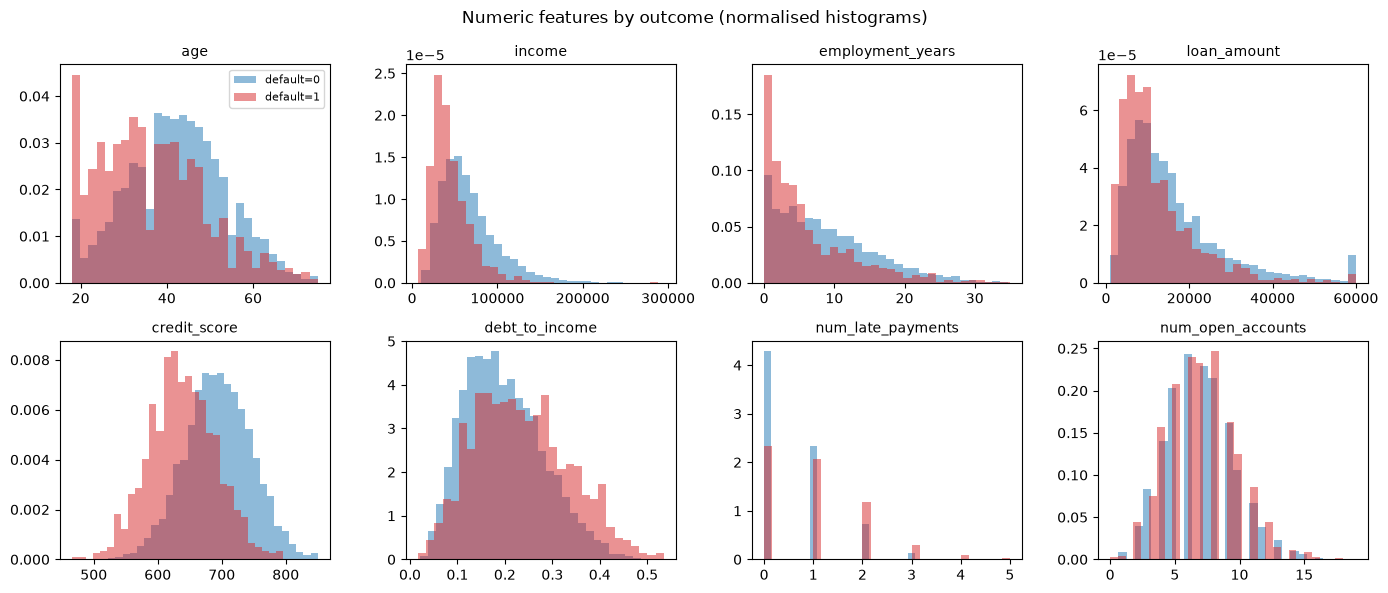

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, col in zip(axes.ravel(), num_cols):
    for lab, color in [(0, "tab:blue"), (1, "tab:red")]:
        vals = df.loc[df[target] == lab, col].dropna()
        ax.hist(vals, bins=30, density=True, alpha=0.5, color=color, label=f"default={lab}")
    ax.set_title(col, fontsize=10)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Numeric features by outcome (normalised histograms)")
plt.tight_layout(); plt.show()

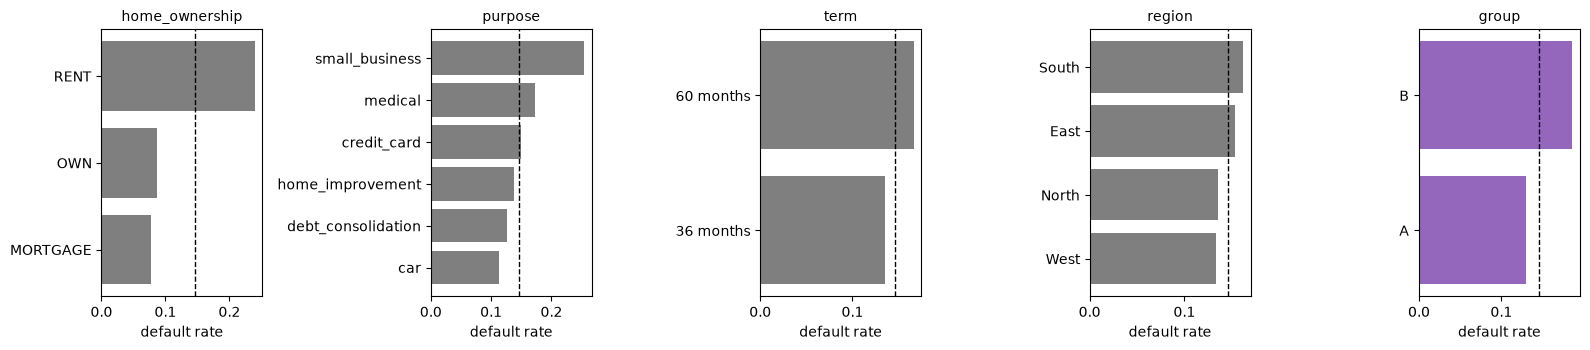

sensitive attribute vs other features (group means):
        income  credit_score  debt_to_income
group                                       
A      69817.6         693.3             0.2
B      49074.3         668.6             0.2

share of group B by region:
 region
East     0.30
North    0.15
South    0.55
West     0.15


In [6]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6))
for ax, col in zip(axes, cat_cols + [sensitive]):
    rates = df.groupby(col)[target].mean().sort_values()
    ax.barh(rates.index.astype(str), rates.values, color="tab:gray" if col != sensitive else "tab:purple")
    ax.axvline(df[target].mean(), color="k", ls="--", lw=1)
    ax.set_title(col, fontsize=10); ax.set_xlabel("default rate")
plt.tight_layout(); plt.show()

print("sensitive attribute vs other features (group means):")
print(df.groupby(sensitive)[["income", "credit_score", "debt_to_income"]].mean().round(1).to_string())
print("\nshare of group B by region:\n", pd.crosstab(df["region"], df[sensitive], normalize="index").round(2)["B"].to_string())

EDA findings that shape the modelling:

- Credit score, debt-to-income and late payments show the strongest separation; relationships look monotone but not necessarily linear (e.g. the default rate climbs much faster once debt-to-income exceeds ~0.3).
- Missingness is present in four columns and is informative (employment years are missing more often for renters), so we will impute **and** add missing-value indicator features.
- Group B has a higher default rate, lower average income, and is concentrated in the South region. Even if we exclude `group` from the features, income and region carry information about it — "fairness through unawareness" will not guarantee equal outcomes (Section 12).

## 5. Train/test split and preprocessing with `ColumnTransformer`

We hold out 25% as a **test set**, stratified on the target so both splits have the same default rate. The sensitive attribute is **removed from the feature matrix** (we keep it aside for the fairness audit): using a protected characteristic directly as an input to credit decisions is prohibited in many jurisdictions.

All preprocessing lives inside a `Pipeline`, so that during cross-validation imputation medians, scaling statistics and one-hot categories are learned on the training folds only — preventing **leakage**:

- numeric: median imputation + missing indicators, then standardisation (needed for regularised logistic regression; harmless for trees);
- categorical: most-frequent imputation, then one-hot encoding with `handle_unknown="ignore"` (unseen categories in production become all-zero rows instead of crashing).

In [7]:
X = df[num_cols + cat_cols]
y = df[target].to_numpy()
g = df[sensitive].to_numpy()
X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, g, test_size=0.25, stratify=y, random_state=SEED)
print(f"train {X_train.shape}, test {X_test.shape}; default rate train {y_train.mean():.3f}, test {y_test.mean():.3f}")

numeric_pipe = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                         ("scale", StandardScaler())])
categorical_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                             ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocess = ColumnTransformer([("num", numeric_pipe, num_cols), ("cat", categorical_pipe, cat_cols)])

Xt = preprocess.fit_transform(X_train)
print("design matrix after preprocessing:", Xt.shape)
print("feature names (first 12):", list(preprocess.get_feature_names_out()[:12]))

train (6000, 12), test (2000, 12); default rate train 0.146, test 0.146
design matrix after preprocessing: (6000, 26)
feature names (first 12): ['num__age', 'num__income', 'num__employment_years', 'num__loan_amount', 'num__credit_score', 'num__debt_to_income', 'num__num_late_payments', 'num__num_open_accounts', 'num__missingindicator_income', 'num__missingindicator_employment_years', 'num__missingindicator_credit_score', 'cat__home_ownership_MORTGAGE']


## 6. Baseline

Every project needs a trivial baseline so that improvements are meaningful. `DummyClassifier(strategy="prior")` predicts the training prevalence for everyone: ROC AUC 0.5, average precision equal to the prevalence, and its best decision is "approve everyone" (cost $C_{FN}\times$ prevalence $\approx 0.63$) or "reject everyone" (cost $C_{FP}\times(1-\text{prevalence})\approx 0.87$), whichever is cheaper.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"roc_auc": "roc_auc", "avg_precision": "average_precision", "brier": "neg_brier_score"}

def cv_summary(model, name):
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    return {"model": name,
            "ROC AUC": res["test_roc_auc"].mean(), "ROC AUC sd": res["test_roc_auc"].std(),
            "avg precision": res["test_avg_precision"].mean(), "Brier": -res["test_brier"].mean(),
            "fit time (s)": res["fit_time"].mean(), "_auc_folds": res["test_roc_auc"]}

baseline = Pipeline([("prep", preprocess), ("clf", DummyClassifier(strategy="prior"))])
rows = [cv_summary(baseline, "Dummy (prior)")]
pd.DataFrame(rows).drop(columns="_auc_folds").round(3)

,model,ROC AUC,ROC AUC sd,avg precision,Brier,fit time (s)
0,Dummy (prior),0.5,0.0,0.146,0.125,0.021


## 7. Candidate models with cross-validation

We compare three model families with 5-fold stratified cross-validation on the training set:

- **Logistic regression** — linear in the (preprocessed) features, well calibrated by construction (it is the MLE of a Bernoulli model), highly interpretable.
- **Random forest** — averages de-correlated deep trees; captures nonlinearity and interactions; probabilities tend to be less well calibrated (pushed away from 0 and 1).
- **Histogram gradient boosting** — additive ensemble of shallow trees fitted to the log-loss gradient; usually the strongest off-the-shelf model for tabular data.

Reporting the fold-to-fold standard deviation reminds us that small differences in CV scores may not be meaningful.

In [9]:
models = {
    "Logistic regression": LogisticRegression(C=1.0, max_iter=2000),
    "Random forest": RandomForestClassifier(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=SEED),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=SEED),
}
t0 = time.time()
for name, clf in models.items():
    rows.append(cv_summary(Pipeline([("prep", preprocess), ("clf", clf)]), name))
cv_table = pd.DataFrame(rows)
print(f"({time.time() - t0:.1f}s)")
cv_table.drop(columns="_auc_folds").round(3)

(5.1s)


,model,ROC AUC,ROC AUC sd,avg precision,Brier,fit time (s)
0,Dummy (prior),0.500,0.000,0.146,0.125,0.021
1,Logistic regression,0.817,0.015,0.501,0.098,0.031
2,Random forest,0.810,0.016,0.468,0.100,0.568
3,HistGradientBoosting,0.786,0.006,0.435,0.105,0.274


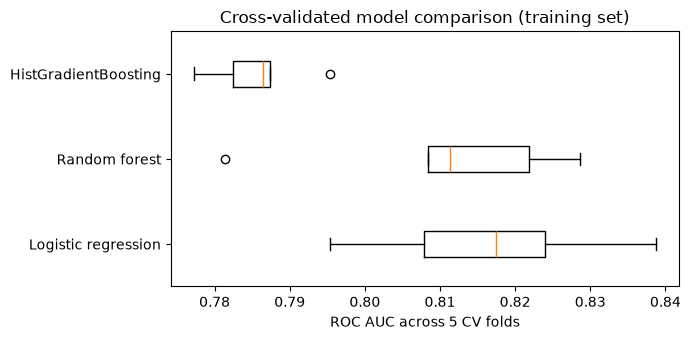

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.5))
data = [r["_auc_folds"] for r in rows[1:]]
ax.boxplot(data, orientation="horizontal")
ax.set_yticks(range(1, len(data) + 1), [r["model"] for r in rows[1:]])
ax.set_xlabel("ROC AUC across 5 CV folds"); ax.set_title("Cross-validated model comparison (training set)")
plt.tight_layout(); plt.show()

Logistic regression is at least as good as the tree ensembles here. That is not a failure of the ensembles: the true log-odds in our simulation are close to additive and mostly monotone, so a linear model on standardised features is nearly well specified, whereas trees must approximate smooth effects by step functions from only 6,000 noisy examples. This happens on real tabular data too: a well-specified linear model is a strong baseline, and gains from complex models must be weighed against interpretability and operational cost. Note the fold-to-fold standard deviation of about 0.015 AUC: the differences between the tuned models are comparable to the noise.

## 8. Hyperparameter search

We tune the two most promising families. For logistic regression, a small **grid** over the inverse regularisation strength $C$. For gradient boosting, a **randomised search** (Bergstra & Bengio, 2012): with a fixed budget, random sampling explores more distinct values of the important hyperparameters than a grid. Key HGB hyperparameters: `learning_rate` (shrinkage), `max_leaf_nodes` / `max_depth` (tree complexity, interaction order), `min_samples_leaf` and `l2_regularization` (regularisation), and `max_iter` with early stopping.

To keep the notebook fast we use 3-fold CV inside the search; the selected configuration is then re-assessed with the same 5-fold CV as the other models. (For an unbiased estimate of a *tuned* model's performance one would use nested CV — we instead rely on the untouched test set.)

In [11]:
t0 = time.time()
lr_search = GridSearchCV(Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=2000))]),
                         {"clf__C": np.logspace(-3, 2, 6)}, cv=3, scoring="roc_auc", n_jobs=1)
lr_search.fit(X_train, y_train)
print(f"logistic regression: best C = {lr_search.best_params_['clf__C']:.3g}, CV AUC = {lr_search.best_score_:.4f}")

param_dist = {
    "clf__learning_rate": stats.loguniform(0.02, 0.3),
    "clf__max_leaf_nodes": stats.randint(4, 32),
    "clf__min_samples_leaf": stats.randint(10, 100),
    "clf__l2_regularization": stats.loguniform(1e-3, 10),
}
hgb_search = RandomizedSearchCV(
    Pipeline([("prep", preprocess),
              ("clf", HistGradientBoostingClassifier(max_iter=300, early_stopping=True, random_state=SEED))]),
    param_dist, n_iter=12, cv=3, scoring="roc_auc", random_state=SEED, n_jobs=1)
hgb_search.fit(X_train, y_train)
print("HGB best params:", {k.replace("clf__", ""): round(float(v), 4) for k, v in hgb_search.best_params_.items()})
print(f"HGB best 3-fold CV AUC = {hgb_search.best_score_:.4f}   ({time.time() - t0:.1f}s)")

rows.append(cv_summary(lr_search.best_estimator_, "Logistic regression (tuned)"))
rows.append(cv_summary(hgb_search.best_estimator_, "HistGradientBoosting (tuned)"))
cv_table = pd.DataFrame(rows).drop(columns="_auc_folds")
cv_table.round(4)

logistic regression: best C = 0.1, CV AUC = 0.8172


HGB best params: {'l2_regularization': 2.7527, 'learning_rate': 0.1262, 'max_leaf_nodes': 12.0, 'min_samples_leaf': 48.0}
HGB best 3-fold CV AUC = 0.8074   (6.9s)


,model,ROC AUC,ROC AUC sd,avg precision,Brier,fit time (s)
0,Dummy (prior),0.500,0.000,0.146,0.125,0.021
1,Logistic regression,0.817,0.015,0.501,0.098,0.031
2,Random forest,0.810,0.016,0.468,0.100,0.568
3,HistGradientBoosting,0.786,0.006,0.435,0.105,0.274
4,Logistic regression (tuned),0.817,0.014,0.501,0.098,0.030
5,HistGradientBoosting (tuned),0.806,0.013,0.465,0.101,0.121


The final model is the tuned candidate with the highest 5-fold CV AUC (chosen programmatically below; with this data it is the regularised logistic regression). Since the top models are within the fold-to-fold noise, a tie-break in favour of the simpler, more interpretable and better-calibrated model would be defensible anyway. We keep the runner-up for comparison.

In [12]:
best_name = cv_table.iloc[-2:].sort_values("ROC AUC").iloc[-1]["model"]
final_model = hgb_search.best_estimator_ if "Gradient" in best_name else lr_search.best_estimator_
runner_up = lr_search.best_estimator_ if "Gradient" in best_name else hgb_search.best_estimator_
runner_name = "Logistic regression (tuned)" if "Gradient" in best_name else "HistGradientBoosting (tuned)"
print("selected model:", best_name, "| runner-up:", runner_name)

selected model: Logistic regression (tuned) | runner-up: HistGradientBoosting (tuned)


## 9. From probabilities to decisions: threshold tuning for a cost matrix

We choose the threshold on the **training data only**, using **out-of-fold** predicted probabilities from `cross_val_predict` — each training point is scored by a model that did not see it, which mimics performance on new data. We then:

1. check calibration (reliability diagram): if $\hat p$ were perfectly calibrated, the empirically optimal threshold would be close to $t^\star = 1/6$;
2. sweep $t\in(0,1)$ and pick the threshold with the lowest average cost;
3. cross-check with scikit-learn's `TunedThresholdClassifierCV`, which automates the same procedure with internal cross-validation.

empirical cost-optimal threshold (OOF): 0.195  cost 0.413
cost at Bayes threshold 0.167: 0.416
cost at default threshold 0.5: 0.585
TunedThresholdClassifierCV threshold: 0.210   (0.4s)


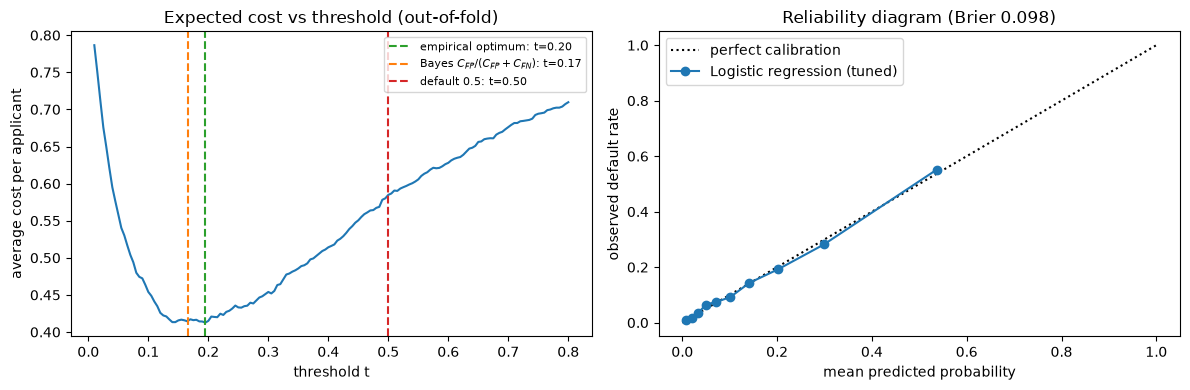

In [13]:
t0 = time.time()
oof = cross_val_predict(final_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
thresholds = np.linspace(0.01, 0.8, 159)
costs = np.array([expected_cost(y_train, (oof >= t).astype(int)) for t in thresholds])
t_best = thresholds[costs.argmin()]
print(f"empirical cost-optimal threshold (OOF): {t_best:.3f}  cost {costs.min():.3f}")
print(f"cost at Bayes threshold {t_bayes:.3f}: {expected_cost(y_train, (oof >= t_bayes).astype(int)):.3f}")
print(f"cost at default threshold 0.5: {expected_cost(y_train, (oof >= 0.5).astype(int)):.3f}")

cost_scorer = make_scorer(lambda yt, yp: -expected_cost(yt, yp))       # higher is better
tuned = TunedThresholdClassifierCV(final_model, scoring=cost_scorer, cv=3, random_state=SEED).fit(X_train, y_train)
print(f"TunedThresholdClassifierCV threshold: {tuned.best_threshold_:.3f}   ({time.time() - t0:.1f}s)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(thresholds, costs)
for t, lab, c in [(t_best, "empirical optimum", "tab:green"), (t_bayes, "Bayes $C_{FP}/(C_{FP}+C_{FN})$", "tab:orange"),
                  (0.5, "default 0.5", "tab:red")]:
    axes[0].axvline(t, ls="--", color=c, label=f"{lab}: t={t:.2f}")
axes[0].set_xlabel("threshold t"); axes[0].set_ylabel("average cost per applicant"); axes[0].legend(fontsize=8)
axes[0].set_title("Expected cost vs threshold (out-of-fold)")
frac_pos, mean_pred = calibration_curve(y_train, oof, n_bins=10, strategy="quantile")
axes[1].plot([0, 1], [0, 1], "k:", label="perfect calibration")
axes[1].plot(mean_pred, frac_pos, "o-", label=best_name)
axes[1].set_xlabel("mean predicted probability"); axes[1].set_ylabel("observed default rate")
axes[1].set_title(f"Reliability diagram (Brier {brier_score_loss(y_train, oof):.3f})"); axes[1].legend()
plt.tight_layout(); plt.show()

The cost curve is fairly flat near its minimum — a useful fact to communicate: small threshold changes cost little, which gives room to accommodate other constraints (e.g. fairness, Section 12). The empirical optimum lands near the Bayes threshold $1/6$ because the model's probabilities are reasonably calibrated; the default 0.5 threshold is far more expensive because it approves too many risky applicants. If calibration were poor (e.g. for a random forest or an SVM), we would either tune the threshold empirically as done here or recalibrate with `CalibratedClassifierCV` (Platt scaling or isotonic regression).

## 10. Final evaluation on the test set

Only now do we refit the selected pipeline on the **full training set** and evaluate **once** on the test set, with the threshold fixed in advance. We attach **bootstrap confidence intervals** (resampling test applicants with replacement) because a single number hides sampling uncertainty — with about 270 defaulters in the test set, the uncertainty is not negligible. We also compare against simple policies and the runner-up model.

In [14]:
final_model.fit(X_train, y_train)
p_test = final_model.predict_proba(X_test)[:, 1]
yhat_test = (p_test >= t_best).astype(int)

def bootstrap_ci(metric, y_true, score, n_boot=500, seed=SEED):
    r = np.random.default_rng(seed); vals = []
    for _ in range(n_boot):
        idx = r.integers(0, len(y_true), len(y_true))
        vals.append(metric(y_true[idx], score[idx]))
    return np.percentile(vals, [2.5, 97.5])

auc = roc_auc_score(y_test, p_test); ap = average_precision_score(y_test, p_test)
cost = expected_cost(y_test, yhat_test)
auc_ci = bootstrap_ci(roc_auc_score, y_test, p_test)
cost_ci = bootstrap_ci(expected_cost, y_test, yhat_test)
runner_up.fit(X_train, y_train)
p_ru = runner_up.predict_proba(X_test)[:, 1]

summary = pd.DataFrame({
    "policy": [f"{best_name} @ t={t_best:.2f}", f"{runner_name} @ t={t_best:.2f}", f"{best_name} @ t=0.50",
               "approve everyone", "reject everyone"],
    "ROC AUC": [auc, roc_auc_score(y_test, p_ru), auc, 0.5, 0.5],
    "avg precision": [ap, average_precision_score(y_test, p_ru), ap, y_test.mean(), y_test.mean()],
    "cost / applicant": [cost, expected_cost(y_test, (p_ru >= t_best).astype(int)),
                         expected_cost(y_test, (p_test >= 0.5).astype(int)),
                         expected_cost(y_test, np.zeros_like(y_test)), expected_cost(y_test, np.ones_like(y_test))],
    "rejection rate": [yhat_test.mean(), (p_ru >= t_best).mean(), (p_test >= 0.5).mean(), 0.0, 1.0],
})
print(f"Test ROC AUC {auc:.3f} (95% bootstrap CI {auc_ci[0]:.3f}-{auc_ci[1]:.3f}); "
      f"cost {cost:.3f} (95% CI {cost_ci[0]:.3f}-{cost_ci[1]:.3f})")
tn, fp, fn, tp = confusion_matrix(y_test, yhat_test).ravel()
print(f"confusion matrix at t={t_best:.2f}: TN={tn} FP={fp} FN={fn} TP={tp}")
summary.round(3)

Test ROC AUC 0.811 (95% bootstrap CI 0.785-0.837); cost 0.421 (95% CI 0.374-0.473)
confusion matrix at t=0.20: TN=1381 FP=327 FN=103 TP=189


,policy,ROC AUC,avg precision,cost / applicant,rejection rate
0,Logistic regression (tuned) @ t=0.20,0.811,0.472,0.421,0.258
1,HistGradientBoosting (tuned) @ t=0.20,0.810,0.450,0.431,0.247
2,Logistic regression (tuned) @ t=0.50,0.811,0.472,0.580,0.054
3,approve everyone,0.500,0.146,0.730,0.000
4,reject everyone,0.500,0.146,0.854,1.000


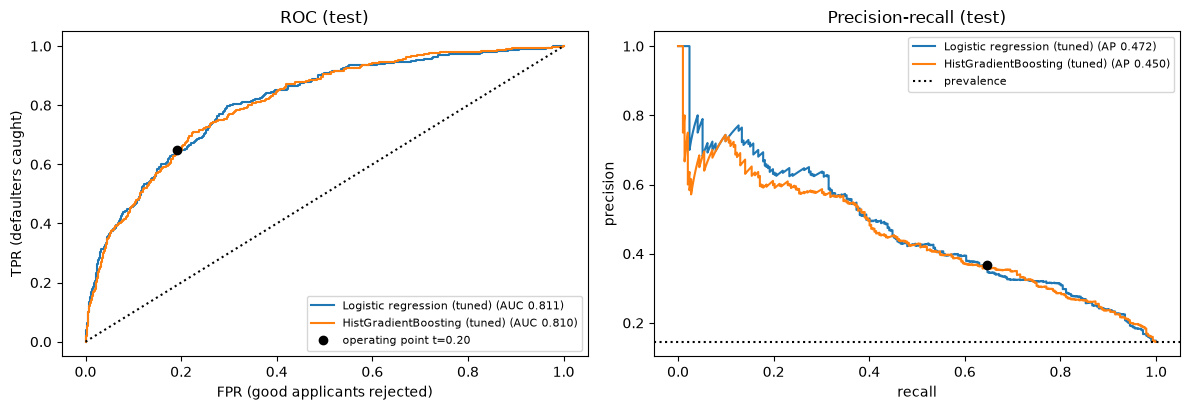

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for p, name in [(p_test, best_name), (p_ru, runner_name)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    prec, rec, _ = precision_recall_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_test, p):.3f})")
    axes[1].plot(rec, prec, label=f"{name} (AP {average_precision_score(y_test, p):.3f})")
# mark the operating point of the chosen threshold
axes[0].plot(fp / (fp + tn), tp / (tp + fn), "ko", label=f"operating point t={t_best:.2f}")
axes[1].plot(tp / (tp + fn), tp / (tp + fp), "ko")
axes[0].plot([0, 1], [0, 1], "k:"); axes[1].axhline(y_test.mean(), color="k", ls=":", label="prevalence")
axes[0].set_xlabel("FPR (good applicants rejected)"); axes[0].set_ylabel("TPR (defaulters caught)"); axes[0].set_title("ROC (test)")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision"); axes[1].set_title("Precision-recall (test)")
for ax in axes: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The tuned model clearly beats both trivial policies and the default 0.5 threshold, and its test AUC agrees with the cross-validated estimate within the bootstrap interval. The runner-up performs almost identically; whichever looks slightly better *on the test set*, switching models now would turn the test set into a validation set and bias the final estimate upward. Differences of a few thousandths in cost per applicant are far inside the confidence interval.

## 11. Model interpretation: permutation importance and partial dependence

**Permutation importance** (Breiman, 2001): the drop in a score when one feature's values are randomly shuffled, breaking its relationship with the target while keeping its marginal distribution:

$$
I_j = s(f; X, y) - \frac1R\sum_{r=1}^{R} s\bigl(f; X^{(j,\pi_r)}, y\bigr).
$$

Applied to the whole pipeline it works on **raw input columns** (each categorical column is permuted as a unit), is model-agnostic and is computed on held-out data. Caveats: correlated features share importance (permuting one while its correlate remains leaves the information available) and permutations can create unrealistic combinations.

**Partial dependence** (Friedman, 2001) shows the average model output as one feature is varied, averaging over the other features:

$$
\operatorname{PD}_j(z) = \frac1n\sum_{i=1}^n \hat f\bigl(z, \mathbf x_{i,-j}\bigr),
$$

and **ICE** curves (Goldstein et al., 2015) show the individual terms, revealing heterogeneity/interactions that the average hides. Both describe the *model*, not causal effects in the world.

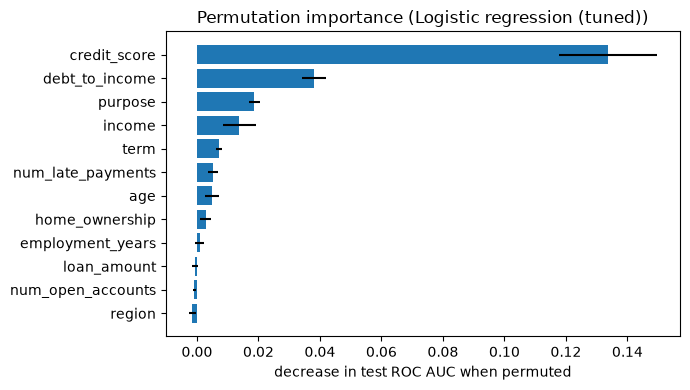

(0.9s)


In [16]:
t0 = time.time()
perm = permutation_importance(final_model, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=SEED, n_jobs=1)
imp = pd.DataFrame({"mean": perm.importances_mean, "std": perm.importances_std}, index=X_test.columns).sort_values("mean")
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp.index, imp["mean"], xerr=imp["std"], color="tab:blue")
ax.set_xlabel("decrease in test ROC AUC when permuted"); ax.set_title(f"Permutation importance ({best_name})")
plt.tight_layout(); plt.show()
print(f"({time.time() - t0:.1f}s)")

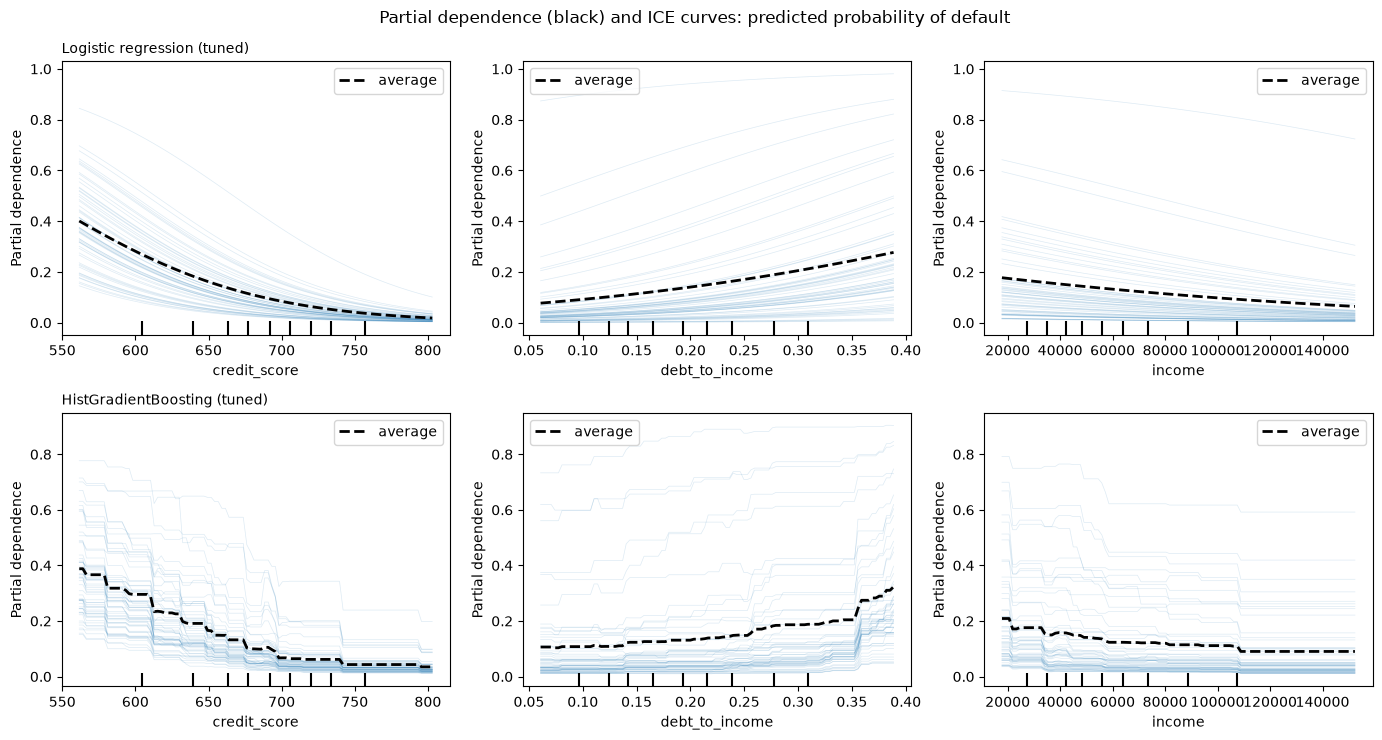

In [17]:
pd_features = ["credit_score", "debt_to_income", "income"]
X_pd = X_test.dropna(subset=pd_features).sample(400, random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for row, (model, name) in enumerate([(final_model, best_name), (runner_up, runner_name)]):
    PartialDependenceDisplay.from_estimator(model, X_pd, pd_features, kind="both", subsample=60, percentiles=(0.02, 0.98),
                                            random_state=SEED, ax=axes[row], ice_lines_kw={"alpha": 0.15},
                                            pd_line_kw={"color": "k", "lw": 2})
    axes[row, 0].set_title(name, loc="left", fontsize=10)
fig.suptitle("Partial dependence (black) and ICE curves: predicted probability of default")
plt.tight_layout(); plt.show()

The interpretation tools recover the structure we put into the simulation: credit score and debt-to-income dominate, followed by purpose, income and term; higher income lowers risk. Late payments rank lower than their direct effect in the true model would suggest because they also act *through* the credit score — correlated features share importance. Region is unimportant — it has no direct effect in the data-generating process — which does *not* mean the model is blind to group membership, as the next section shows.

Comparing the two rows is instructive. For logistic regression the PDP in each feature is a sigmoid of a linear function, and the ICE curves are shifted and rescaled copies of each other (the model is additive in log-odds). The tree ensemble is free to bend: its debt-to-income curve bends upward sharply at around 0.3–0.35, reflecting the hinge we built into the true log-odds, and its ICE curves reveal some heterogeneity. Such plots are a good way to find transformations (e.g. a hinge feature $\max(0, \text{DTI}-0.3)$) that would improve the linear model — try it.

## 12. Fairness analysis

Let $A\in\{A, B\}$ be the sensitive attribute, $Y$ the outcome and $\hat Y$ the decision ($\hat Y=1$: reject). Common group-fairness criteria (Barocas, Hardt & Narayanan, 2023):

- **Demographic (statistical) parity**: $P(\hat Y=1\mid A=a)$ equal across groups. Difference: $\Delta_{DP} = |P(\hat Y=1\mid A)-P(\hat Y=1\mid B)|$.
- **Equalised odds** (Hardt, Price & Srebro, 2016): equal TPR **and** equal FPR across groups, i.e. $\hat Y \perp A \mid Y$. Difference: $\Delta_{EO} = \max\bigl(|\Delta \text{TPR}|, |\Delta\text{FPR}|\bigr)$. Here a high FPR means *creditworthy applicants wrongly rejected* — the most direct harm to applicants.
- **Equal opportunity**: equal TPR only (or, from the applicant's side, equal FPR only).
- **Calibration within groups / predictive parity**: $P(Y=1\mid \hat p = s, A=a) = s$ for all groups.

**Impossibility.** When base rates differ between groups ($P(Y=1\mid A)$ differs, as here), a non-perfect classifier cannot simultaneously satisfy calibration within groups and equal FPR and FNR (Kleinberg, Mullainathan & Raghavan, 2016; Chouldechova, 2017). Choosing a criterion is a normative and legal decision, not a purely technical one.

**Unawareness is not fairness.** We did not use `group` as a feature, but income and region are correlated with it. Below we (1) measure how predictable `group` is from the features (proxy strength), (2) compute group-wise metrics of our decisions, and (3) try a simple post-processing mitigation: group-specific thresholds that equalise FPR.

In [18]:
# (1) proxy check: can the features predict the sensitive attribute?
proxy = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=2000))])
proxy_auc = cross_validate(proxy, X_train, (g_train == "B").astype(int), cv=3, scoring="roc_auc")["test_score"].mean()
print(f"AUC for predicting group membership from the model's input features: {proxy_auc:.3f}")

# (2) group-wise metrics, computed manually
def group_report(y_true, y_pred, groups, scores=None):
    rows = []
    for a in np.unique(groups):
        m = groups == a
        yt, yp = y_true[m], y_pred[m]
        rows.append({"group": a, "n": m.sum(), "base rate P(Y=1)": yt.mean(),
                     "rejection rate P(Yhat=1)": yp.mean(),
                     "TPR (defaulters caught)": yp[yt == 1].mean(),
                     "FPR (good applicants rejected)": yp[yt == 0].mean(),
                     "precision": yt[yp == 1].mean() if yp.sum() else np.nan,
                     "AUC": roc_auc_score(yt, scores[m]) if scores is not None else np.nan,
                     "cost / applicant": expected_cost(yt, yp)})
    return pd.DataFrame(rows).set_index("group")

def fairness_gaps(rep):
    dp = abs(rep["rejection rate P(Yhat=1)"].diff().iloc[-1])
    tpr_gap = abs(rep["TPR (defaulters caught)"].diff().iloc[-1])
    fpr_gap = abs(rep["FPR (good applicants rejected)"].diff().iloc[-1])
    return {"demographic parity diff": dp, "TPR diff": tpr_gap, "FPR diff": fpr_gap,
            "equalized odds diff": max(tpr_gap, fpr_gap)}

rep = group_report(y_test, yhat_test, g_test, p_test)
gaps = fairness_gaps(rep)
display(rep.round(3))
print({k: round(float(v), 3) for k, v in gaps.items()})

AUC for predicting group membership from the model's input features: 0.778


,n,base rate P(Y=1),rejection rate P(Yhat=1),TPR (defaulters caught),FPR (good applicants rejected),precision,AUC,cost / applicant
group,,,,,,,,
A,1430,0.122,0.206,0.580,0.154,0.344,0.799,0.390
B,570,0.207,0.389,0.746,0.296,0.396,0.814,0.498


{'demographic parity diff': 0.184, 'TPR diff': 0.165, 'FPR diff': 0.143, 'equalized odds diff': 0.165}


Group B has a higher base rate of default in this simulated population (driven entirely by lower incomes — there is no direct effect of group), and the model, which ranks risk well in *both* groups (similar within-group AUC), rejects group B applicants more often, including more **creditworthy** group B applicants (higher FPR). Check the table: exact values vary with the sample, and with only a few hundred group-B test applicants each rate has a standard error of several percentage points. Whether this is acceptable depends on context: the higher base rate may itself reflect historical injustice, the features may be measured with different quality across groups, and the law may prohibit disparate impact in lending.

**Post-processing mitigation.** One option in the spirit of Hardt et al. (2016) is to use **group-specific thresholds** chosen on training out-of-fold predictions so that FPRs are equal. This requires knowing group membership at decision time, which is itself legally sensitive (disparate treatment); alternatives include in-processing constraints (e.g. fairness-regularised training) and pre-processing (reweighing), and — often most effective — fixing data collection and features.

group-specific thresholds: {'A': 0.171, 'B': 0.249}


,single threshold,group thresholds (equal FPR)
demographic parity diff,0.184,0.061
TPR diff,0.165,0.049
FPR diff,0.143,0.018
equalized odds diff,0.165,0.049
overall cost,0.421,0.430


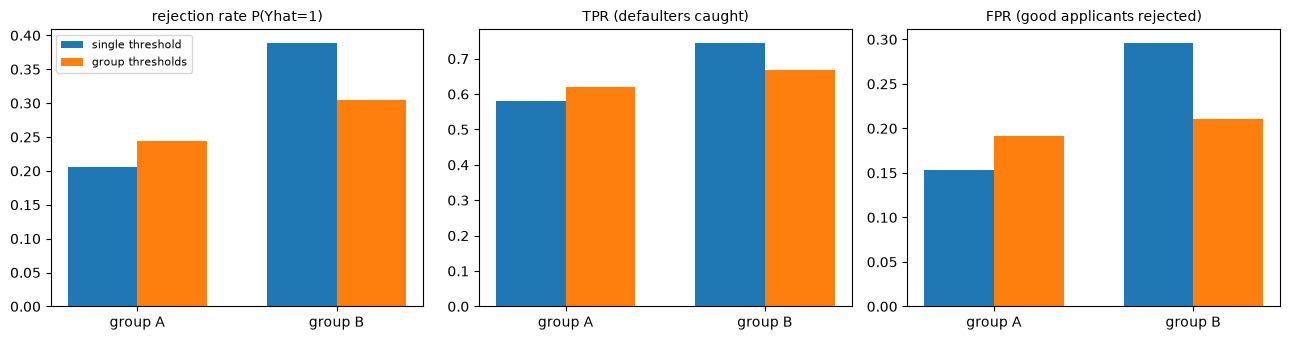

In [19]:
# (3) group-specific thresholds equalising FPR, chosen on TRAINING out-of-fold scores
def fpr_at(scores, y_true, t):
    return (scores[y_true == 0] >= t).mean()

target_fpr = fpr_at(oof, y_train, t_best)                     # overall FPR at the cost-optimal threshold
t_group = {}
for a in ["A", "B"]:
    m = g_train == a
    cand = np.linspace(0.01, 0.9, 400)
    t_group[a] = cand[np.argmin([abs(fpr_at(oof[m], y_train[m], t) - target_fpr) for t in cand])]
print("group-specific thresholds:", {k: round(float(v), 3) for k, v in t_group.items()})

yhat_fair = (p_test >= np.where(g_test == "A", t_group["A"], t_group["B"])).astype(int)
rep_fair = group_report(y_test, yhat_fair, g_test, p_test)
gaps_fair = fairness_gaps(rep_fair)

comparison = pd.DataFrame({"single threshold": {**gaps, "overall cost": expected_cost(y_test, yhat_test)},
                           "group thresholds (equal FPR)": {**gaps_fair, "overall cost": expected_cost(y_test, yhat_fair)}})
display(comparison.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, ["rejection rate P(Yhat=1)", "TPR (defaulters caught)", "FPR (good applicants rejected)"]):
    width = 0.35
    x = np.arange(2)
    ax.bar(x - width / 2, rep[col], width, label="single threshold")
    ax.bar(x + width / 2, rep_fair[col], width, label="group thresholds")
    ax.set_xticks(x, ["group A", "group B"]); ax.set_title(col, fontsize=10)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

Equalising FPR on the training data substantially reduces the FPR gap on the test set, typically at a small increase in overall cost — because the cost curve is flat near the optimum (Section 9). Note that with only a few hundred group-B test applicants these rates carry noticeable sampling error, and that the mitigation leaves demographic parity unmet: fairness criteria genuinely conflict, and the choice must be documented and justified.

## 13. Documentation: a model card

A **model card** (Mitchell et al., 2019) is a short, standardised document shipped with a model: intended use and out-of-scope uses, training data, evaluation metrics (including disaggregated by group), ethical considerations, caveats and maintenance information. Its companion for datasets is the **datasheet** (Gebru et al., 2021). Generating the card from the same code that computed the metrics keeps the documentation in sync with the model.

In [20]:
card = f"""
### Model card: loan default risk model (course example)

**Model details.** `{best_name}` in a scikit-learn {sklearn.__version__} pipeline (median/mode imputation with missing indicators,
standardisation, one-hot encoding). Decision threshold t = {t_best:.2f} on the predicted default probability (reject if above).
Version 1.0, trained {date.today().isoformat()}. Owner: course data-science team.

**Intended use.** Decision *support* for consumer loan applications, with human review of rejections. Not intended for
pricing, for applicants outside the training population, or for fully automated adverse decisions.

**Training data.** {len(X_train)} simulated applications (synthetic, generated by `make_loan_data`, seed 42), default rate
{y_train.mean():.1%}. Features: {", ".join(num_cols + cat_cols)}. The sensitive attribute `group` is excluded from the inputs
and used only for auditing.

**Evaluation (held-out test set, n = {len(y_test)}).** ROC AUC {auc:.3f} (95% CI {auc_ci[0]:.3f}-{auc_ci[1]:.3f}); average precision
{ap:.3f}; expected cost {cost:.3f} per applicant with C_FP = {C_FP:.0f}, C_FN = {C_FN:.0f} (approve-all: {expected_cost(y_test, np.zeros_like(y_test)):.3f}).

**Disaggregated results.** Rejection rate A/B: {rep.loc['A', 'rejection rate P(Yhat=1)']:.1%} / {rep.loc['B', 'rejection rate P(Yhat=1)']:.1%};
FPR A/B: {rep.loc['A', 'FPR (good applicants rejected)']:.1%} / {rep.loc['B', 'FPR (good applicants rejected)']:.1%};
TPR A/B: {rep.loc['A', 'TPR (defaulters caught)']:.1%} / {rep.loc['B', 'TPR (defaulters caught)']:.1%};
equalised-odds difference {gaps['equalized odds diff']:.3f}; demographic-parity difference {gaps['demographic parity diff']:.3f}.

**Ethical considerations.** Input features (income, region) are proxies for the sensitive attribute (proxy AUC {proxy_auc:.2f}).
Creditworthy group-B applicants are rejected more often. A group-threshold mitigation reduces the FPR gap to
{gaps_fair['FPR diff']:.3f} at a cost increase of {expected_cost(y_test, yhat_fair) - cost:+.3f} per applicant; legal review is required before use.

**Caveats and monitoring.** Performance will degrade under economic shifts (see drift analysis). Monitor input drift (PSI)
weekly, and default rates/calibration as outcomes mature; retrain or recalibrate when PSI > 0.25 on key features
or when calibration drifts materially.
"""
display(Markdown(card))


### Model card: loan default risk model (course example)

**Model details.** `Logistic regression (tuned)` in a scikit-learn 1.9.1 pipeline (median/mode imputation with missing indicators,
standardisation, one-hot encoding). Decision threshold t = 0.20 on the predicted default probability (reject if above).
Version 1.0, trained 2026-09-24. Owner: course data-science team.

**Intended use.** Decision *support* for consumer loan applications, with human review of rejections. Not intended for
pricing, for applicants outside the training population, or for fully automated adverse decisions.

**Training data.** 6000 simulated applications (synthetic, generated by `make_loan_data`, seed 42), default rate
14.6%. Features: age, income, employment_years, loan_amount, credit_score, debt_to_income, num_late_payments, num_open_accounts, home_ownership, purpose, term, region. The sensitive attribute `group` is excluded from the inputs
and used only for auditing.

**Evaluation (held-out test set, n = 2000).** ROC AUC 0.811 (95% CI 0.785-0.837); average precision
0.472; expected cost 0.421 per applicant with C_FP = 1, C_FN = 5 (approve-all: 0.730).

**Disaggregated results.** Rejection rate A/B: 20.6% / 38.9%;
FPR A/B: 15.4% / 29.6%;
TPR A/B: 58.0% / 74.6%;
equalised-odds difference 0.165; demographic-parity difference 0.184.

**Ethical considerations.** Input features (income, region) are proxies for the sensitive attribute (proxy AUC 0.78).
Creditworthy group-B applicants are rejected more often. A group-threshold mitigation reduces the FPR gap to
0.018 at a cost increase of +0.010 per applicant; legal review is required before use.

**Caveats and monitoring.** Performance will degrade under economic shifts (see drift analysis). Monitor input drift (PSI)
weekly, and default rates/calibration as outcomes mature; retrain or recalibrate when PSI > 0.25 on key features
or when calibration drifts materially.


## 14. Deployment: persistence, monitoring and data drift

### 14.1 Persisting the model

Persist the **entire pipeline** (preprocessing + model), the decision threshold and metadata (library versions, feature schema, training date, metrics) together. `joblib` pickles scikit-learn objects efficiently. Pickles are tied to library versions and **executing an untrusted pickle can run arbitrary code** — only load artefacts you produced (alternatives: `skops.io`, ONNX). At prediction time, validate the input schema before scoring.

In [21]:
artifact = {"pipeline": final_model, "threshold": float(t_best), "features": num_cols + cat_cols,
            "sklearn_version": sklearn.__version__, "trained_on": date.today().isoformat(),
            "metrics": {"test_auc": float(auc), "test_cost": float(cost)}}

def validate_and_score(art, batch):
    # minimal schema validation before scoring
    missing = set(art["features"]) - set(batch.columns)
    if missing:
        raise ValueError(f"missing columns: {sorted(missing)}")
    p = art["pipeline"].predict_proba(batch[art["features"]])[:, 1]
    return pd.DataFrame({"p_default": p, "decision": np.where(p >= art["threshold"], "reject", "approve")},
                        index=batch.index)

with tempfile.TemporaryDirectory() as tmp:
    path = os.path.join(tmp, "loan_model.joblib")
    joblib.dump(artifact, path)
    print(f"saved {os.path.basename(path)} ({os.path.getsize(path) / 1024:.0f} KiB)")
    loaded = joblib.load(path)

same = np.allclose(loaded["pipeline"].predict_proba(X_test)[:, 1], p_test)
print("reloaded pipeline reproduces test predictions:", same, "| sklearn", loaded["sklearn_version"])
new_applicants = X_test.head(3).copy()
new_applicants.loc[new_applicants.index[0], "purpose"] = "wedding"      # unseen category is handled
display(validate_and_score(loaded, new_applicants).round(3))
try:
    validate_and_score(loaded, new_applicants.drop(columns="credit_score"))
except ValueError as e:
    print("schema check caught:", e)

saved loan_model.joblib (6 KiB)
reloaded pipeline reproduces test predictions: True | sklearn 1.9.1


,p_default,decision
1146,0.298,reject
752,0.061,approve
7331,0.131,approve


schema check caught: missing columns: ['credit_score']


### 14.2 Monitoring and data drift

After deployment, the world changes. Types of drift:

- **Covariate (data) drift**: $P(\mathbf x)$ changes (e.g. a recession lowers incomes, a marketing campaign attracts a different population).
- **Prior (label) drift**: $P(y)$ changes (default rates rise).
- **Concept drift**: $P(y\mid\mathbf x)$ changes (the same profile becomes riskier).

Labels (defaults) arrive with long delays, so monitoring relies first on **inputs and predictions**. A standard statistic in credit scoring is the **population stability index** between a reference distribution (training) and a production batch, over bins $b$:

$$
\text{PSI} = \sum_b (q_b - p_b)\,\ln\frac{q_b}{p_b},
$$

where $p_b$, $q_b$ are the reference and production bin proportions (it is the symmetrised KL divergence). Rules of thumb: $<0.1$ stable, $0.1$–$0.25$ moderate shift, $>0.25$ major shift. For numeric features the two-sample **Kolmogorov–Smirnov** test is a complementary check (but with large samples it flags even tiny, harmless differences — look at effect sizes). Missing-value rates and unseen categories should be tracked too.

We simulate a production batch during an economic downturn (`shift=True`: lower incomes, more late payments, more small-business loans, more missing credit scores).

In [22]:
def psi(ref, new, bins=10, categorical=False, eps=1e-4):
    if categorical:
        cats = sorted(set(ref.dropna()) | set(new.dropna()))
        p = ref.value_counts(normalize=True).reindex(cats, fill_value=0).to_numpy()
        q = new.value_counts(normalize=True).reindex(cats, fill_value=0).to_numpy()
    else:
        ref, new = ref.dropna(), new.dropna()
        edges = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
        edges[0], edges[-1] = -np.inf, np.inf
        p = np.histogram(ref, edges)[0] / len(ref)
        q = np.histogram(new, edges)[0] / len(new)
    p, q = np.clip(p, eps, None), np.clip(q, eps, None)
    return float(np.sum((q - p) * np.log(q / p)))

prod_normal = make_loan_data(n=1500, seed=7)                 # same conditions as training
prod_shift = make_loan_data(n=1500, seed=8, shift=True)      # economic downturn

drift = []
for col in num_cols + cat_cols:
    is_cat = col in cat_cols
    row = {"feature": col, "PSI (normal batch)": psi(X_train[col], prod_normal[col], categorical=is_cat),
           "PSI (downturn batch)": psi(X_train[col], prod_shift[col], categorical=is_cat),
           "missing rate train": X_train[col].isna().mean(), "missing rate downturn": prod_shift[col].isna().mean()}
    if not is_cat:
        row["KS p-value (downturn)"] = stats.ks_2samp(X_train[col].dropna(), prod_shift[col].dropna()).pvalue
    drift.append(row)
drift = pd.DataFrame(drift).set_index("feature")
# PSI of the model's own output score is a useful single summary
drift.loc["model score"] = [psi(pd.Series(oof), pd.Series(final_model.predict_proba(prod_normal[num_cols + cat_cols])[:, 1])),
                            psi(pd.Series(oof), pd.Series(final_model.predict_proba(prod_shift[num_cols + cat_cols])[:, 1])),
                            np.nan, np.nan, np.nan]
drift.round(3)

,PSI (normal batch),PSI (downturn batch),missing rate train,missing rate downturn,KS p-value (downturn)
feature,,,,,
age,0.006,0.003,0.000,0.000,0.991
income,0.005,0.386,0.042,0.045,0.000
employment_years,0.015,0.009,0.080,0.091,0.867
loan_amount,0.009,0.172,0.000,0.000,0.000
credit_score,0.008,0.365,0.053,0.147,0.000
debt_to_income,0.010,0.008,0.000,0.000,0.085
num_late_payments,0.003,0.354,0.000,0.000,0.000
num_open_accounts,0.006,0.005,0.000,0.000,0.977
home_ownership,0.000,0.052,0.019,0.021,NaN


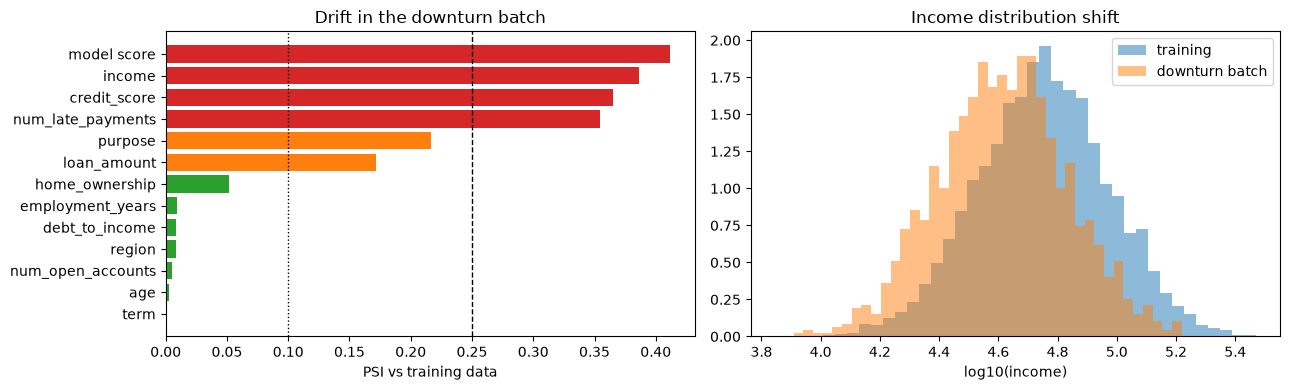

normal batch    default rate 0.146 | mean predicted 0.152 | AUC 0.826 | cost 0.393 | rejection rate 0.267
downturn batch  default rate 0.291 | mean predicted 0.260 | AUC 0.784 | cost 0.586 | rejection rate 0.481


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
d = drift["PSI (downturn batch)"].sort_values()
axes[0].barh(d.index, d.values, color=np.where(d.values > 0.25, "tab:red", np.where(d.values > 0.1, "tab:orange", "tab:green")))
axes[0].axvline(0.1, color="k", ls=":", lw=1); axes[0].axvline(0.25, color="k", ls="--", lw=1)
axes[0].set_xlabel("PSI vs training data"); axes[0].set_title("Drift in the downturn batch")
axes[1].hist(np.log10(X_train["income"].dropna()), bins=40, density=True, alpha=0.5, label="training")
axes[1].hist(np.log10(prod_shift["income"].dropna()), bins=40, density=True, alpha=0.5, label="downturn batch")
axes[1].set_xlabel("log10(income)"); axes[1].legend(); axes[1].set_title("Income distribution shift")
plt.tight_layout(); plt.show()

# Once labels mature, check realised performance and calibration
for name, batch in [("normal batch", prod_normal), ("downturn batch", prod_shift)]:
    p = final_model.predict_proba(batch[num_cols + cat_cols])[:, 1]
    yb = batch[target].to_numpy()
    print(f"{name:15s} default rate {yb.mean():.3f} | mean predicted {p.mean():.3f} | AUC {roc_auc_score(yb, p):.3f} "
          f"| cost {expected_cost(yb, (p >= t_best).astype(int)):.3f} | rejection rate {(p >= t_best).mean():.3f}")

The downturn shows up clearly in the drift report (income, late payments, credit score and its missing rate, purpose, and the model score itself), while every feature of the normal batch stays well below the 0.1 PSI level. The KS test flags the same numeric features. In our simulation the downturn operates only through the features — the true $P(y\mid\mathbf x)$ is unchanged, i.e. pure **covariate shift** — so the model's predicted risk rises along with the realised default rate. It need not track it exactly: a model that is only approximately right (here, an additive model of a non-additive truth) can be miscalibrated in regions of feature space that were rare in training. Meanwhile the **rejection rate rises** sharply, which has business and fairness consequences that should trigger a review. Under **concept drift** ($P(y\mid\mathbf x)$ changes) input monitoring can miss the problem entirely, and only labelled production data and retraining or recalibration help (Exercise 5).

**A deployment checklist**

- Version everything: code, data snapshot, pipeline artefact, threshold, and the model card.
- Shadow deployment or A/B test before switching over; a human-in-the-loop for adverse decisions and a route for applicants to contest them.
- Monitor inputs (PSI, missing rates, unseen categories), outputs (score distribution, rejection rate, by group), and — when labels arrive — AUC, calibration, cost and fairness metrics.
- Define retraining triggers and a rollback plan in advance; watch for **feedback loops** (rejected applicants never generate labels, so future training data are censored by today's model — "reject inference" problem).

## 15. Pitfalls & practical tips

- **Leakage** is the most common reason a model looks great offline and fails in production: fit all preprocessing inside the CV pipeline; exclude features that are only known after the outcome (e.g. "number of collection calls"); split by time or by entity when the data have temporal or group structure.
- **Touch the test set once.** Iterating on test results turns it into a validation set and biases the final estimate upward.
- **Accuracy on imbalanced data is misleading.** Use ROC AUC / average precision for ranking and an explicit cost or utility for decisions. Do not blindly rebalance classes (SMOTE, class weights) — it distorts probabilities; adjust the threshold instead, or recalibrate.
- **Report uncertainty** (CV standard deviations, bootstrap CIs) and do not over-interpret differences within the noise.
- **Calibration matters** whenever probabilities feed decisions or are shown to people.
- **Interpretation is not causation.** Partial dependence and permutation importance describe the model; correlated features make both hard to read.
- **Fairness is not solved by dropping the sensitive attribute.** Audit disaggregated metrics, check proxies, and involve domain, legal and affected stakeholders in choosing a criterion.
- **Plan for drift and feedback loops** before deployment, and document everything (model card, datasheet).

## 16. Exercises

**Exercise 1 (pen and paper, decision theory).** (a) Generalise the Bayes threshold to a cost matrix with non-zero diagonal entries $C_{TN}, C_{TP}$ (e.g. a negative cost, i.e. profit, for a correctly approved good loan). (b) Suppose costs depend on the applicant: $C_{FN}(\mathbf x) = 0.6\times\text{loan amount}$ and $C_{FP}(\mathbf x) = 0.1\times\text{loan amount}$. Show that the optimal decision rule is still a threshold on $\hat p$ and find it. What changes if $C_{FP}$ is constant but $C_{FN}$ scales with the loan amount?

**Exercise 2 (pen and paper, fairness impossibility).** Let a group have base rate $\pi$, and let a classifier have positive predictive value PPV, FPR and FNR in that group. Show that
$$\text{FPR} = \frac{\pi}{1-\pi}\,\frac{1-\text{PPV}}{\text{PPV}}\,(1-\text{FNR}).$$
Conclude that if two groups have different base rates and equal PPV, they cannot have both equal FPR and equal FNR unless the classifier is perfect (Chouldechova, 2017).

**Exercise 3 (coding, calibration).** Wrap the random forest in `CalibratedClassifierCV` (isotonic and sigmoid) and compare reliability diagrams, Brier scores and the empirically optimal thresholds with the uncalibrated forest. How close does each get to $t^\star = 1/6$?

**Exercise 4 (coding, loan-amount-dependent costs).** Implement the cost model of Exercise 1(b) and re-tune the decision rule. Compare total cost and group-wise FPR with the constant-cost policy.

**Exercise 5 (coding, concept drift).** Modify `make_loan_data` so that under `shift=True` the intercept of the true log-odds increases by 0.5 (the same profile becomes riskier). Show that PSI on the inputs cannot detect this, but calibration on labelled production data can. Propose and implement a cheap fix (e.g. recalibrating the intercept on recent labelled data).

**Exercise 6 (coding, in-processing fairness).** Train a logistic regression with sample weights chosen so that each (group, label) cell has equal total weight (the "reweighing" method of Kamiran & Calders, 2012). Compare its equalised-odds difference, demographic parity difference and cost with Section 12.

In [24]:
# Exercise 3 starter
from sklearn.calibration import CalibratedClassifierCV

def calibrated_forest(method="isotonic"):
    # TODO: return a Pipeline([("prep", preprocess), ("clf", CalibratedClassifierCV(RandomForestClassifier(...), method=method, cv=3))])
    return None

# Exercise 4 starter
def expected_cost_amount(y_true, y_pred, loan_amount):
    # TODO: C_FN = 0.6 * loan_amount for missed defaulters, C_FP = 0.1 * loan_amount for rejected good applicants;
    #       return the average cost per applicant
    pass

# Exercise 6 starter
def reweighing_weights(y, groups):
    # TODO: weight w(a, y) = P(A=a) P(Y=y) / P(A=a, Y=y) (Kamiran & Calders, 2012)
    pass

## 17. Capstone assignment brief and grading rubric

**Task.** Carry out an end-to-end supervised learning project and report it as a single, fully reproducible Jupyter notebook (executes top to bottom on CPU in under 10 minutes) plus a 2-page model card.

**Data.** Choose one:

1. a scikit-learn bundled dataset (`load_breast_cancer`, `load_wine`, `load_diabetes`, `load_digits`) reframed with a realistic decision problem and cost structure; or
2. your own synthetic generator in the style of Section 2, for a domain of your choice (e.g. hospital readmission, churn, fraud, insurance claims), with numeric and categorical features, realistic missingness, imbalance and at least one sensitive attribute. You must document and justify the generator's assumptions.

**Required components.**

1. *Problem framing*: stakeholders, decision, costs/utilities, primary and secondary metrics, and why.
2. *EDA*: data quality, missingness mechanisms, target relationships, sensitive-attribute relationships.
3. *Leakage-free pipeline*: `Pipeline`/`ColumnTransformer`, a documented split strategy, a trivial baseline.
4. *Modelling*: at least three model families including one implemented or substantially extended by you (e.g. your NumPy MLP from Lecture 10 or a PyTorch model from Lecture 11), cross-validated comparison with uncertainty, and hyperparameter search.
5. *Decision making*: threshold or policy optimisation for your cost structure, and a calibration assessment.
6. *Final evaluation*: single use of the test set, confidence intervals, comparison with baselines.
7. *Interpretation*: global (permutation importance, PDP/ICE) and at least one local explanation of an individual decision.
8. *Responsible ML*: disaggregated metrics, at least two fairness criteria, a proxy analysis, one mitigation with its trade-offs, and a discussion of what the metrics cannot capture.
9. *Deployment plan*: persistence, schema validation, a drift simulation with monitoring statistics, retraining triggers.
10. *Model card* following Mitchell et al. (2019).

**Grading rubric (100 points).**

| Criterion | Weight | Excellent (90–100%) | Adequate (60–75%) | Insufficient (< 50%) |
|---|---|---|---|---|
| Problem framing & metric choice | 10 | Costs/metrics derived from the decision; trade-offs argued | Sensible metrics, weak justification | Accuracy by default; no link to decision |
| Data & EDA | 10 | Missingness mechanisms and proxies analysed; findings drive design | Standard summaries and plots | Little or no EDA |
| Pipeline & validation methodology | 15 | Leakage-free, correct CV, test used once, baseline | Minor methodological slips | Leakage or test-set tuning |
| Modelling & tuning | 15 | Well-motivated models incl. own implementation; uncertainty reported | Several models, default settings | Single model, no comparison |
| Decision threshold & calibration | 10 | Cost-optimal policy with calibration analysis | Threshold tuned without calibration check | Default 0.5 threshold |
| Interpretation | 10 | Global + local, caveats discussed | Global importance only | None or misinterpreted as causal |
| Fairness & responsible ML | 15 | Multiple criteria, proxy analysis, mitigation with trade-offs, limits discussed | Group metrics reported | Not addressed |
| Deployment, monitoring & model card | 10 | Persisted artefact, drift simulation, triggers, complete model card | Partial plan or card | Missing |
| Reproducibility & communication | 5 | Seeds, clean narrative, runs top to bottom | Minor issues | Does not run / hard to follow |

Deductions: up to $-20$ for a notebook that does not execute cleanly; late policy as per the course syllabus. Academic integrity: cite all sources, including AI assistance, as required by the course policy.

## 18. Summary

- Most of an ML project is framing, data handling, evaluation and responsible deployment — the learning algorithm is one step among many.
- Separate *ranking quality* (ROC AUC, average precision, calibration) from *decision quality* (expected cost). The Bayes threshold $C_{FP}/(C_{FP}+C_{FN})$ applies to calibrated probabilities; otherwise tune the threshold on out-of-fold predictions.
- Put all preprocessing inside a `Pipeline` with `ColumnTransformer`; compare against a dummy baseline; use CV with uncertainty for model selection and touch the test set once.
- Gradient boosting is a strong default for tabular data, but a well-specified logistic regression can be nearly as good and far more transparent.
- Permutation importance and PDP/ICE explain the model (not the world) and recovered the known data-generating structure.
- Removing a sensitive attribute does not remove disparities when proxies exist. Measure group-wise TPR/FPR, demographic parity and equalised odds; fairness criteria conflict when base rates differ, so the choice is normative and must be documented.
- Ship models with a model card, persist the full pipeline with metadata, validate inputs, and monitor drift (PSI, KS, missingness, score distribution) and performance once labels arrive.

## Further reading

- Géron, *Hands-On Machine Learning* (3rd ed.): Ch. 2 (an end-to-end machine learning project).
- James et al., *ISLP* (2023): Ch. 4 (classification), Ch. 5 (resampling), Ch. 8 (tree-based methods).
- Hastie, Tibshirani & Friedman, *ESL* (2009): Ch. 7 (model assessment and selection), Ch. 10 (boosting), Ch. 15 (random forests).
- Murphy, *Probabilistic Machine Learning: An Introduction* (2022): Ch. 5 (decision theory), Ch. 18 (trees and ensembles); *Advanced Topics* (2023): Ch. 19 (distribution shift).
- Bishop, *PRML* (2006): §1.5 (decision theory, loss matrices, reject option).
- Barocas, Hardt & Narayanan, *Fairness and Machine Learning: Limitations and Opportunities* (MIT Press, 2023).
- Molnar, *Interpretable Machine Learning* (2nd ed., 2022): permutation importance, PDP, ICE.
- Hardt, Price & Srebro (2016), "Equality of opportunity in supervised learning"; Kleinberg, Mullainathan & Raghavan (2016), "Inherent trade-offs in the fair determination of risk scores"; Chouldechova (2017), "Fair prediction with disparate impact".
- Mitchell et al. (2019), "Model cards for model reporting"; Gebru et al. (2021), "Datasheets for datasets".
- Sculley et al. (2015), "Hidden technical debt in machine learning systems"; Breck et al. (2017), "The ML test score: a rubric for ML production readiness".
- Friedman (2001), "Greedy function approximation: a gradient boosting machine"; Breiman (2001), "Random forests"; Goldstein et al. (2015), "Peeking inside the black box: ICE plots".